# 03 - Baseline Forecasting
## APEAJAL - Pronóstico de Precios de Aguacate

**Objetivo:** Explorar una gama diversa de técnicas y enfoques con el fin de identificar el mejor deseméño para el problema de precicción de precios. Encontrar la configuración óptima que maximiza el rendimiento del modelo en la predicción de precios.

**Acciones a abordar:**
1. Contruir al menos 6 modelos diferentes (individuales, no ensambles), utilizando algoritmos variados.
2. Comparar el rendimiento de los modelos obtenidos.
3. Seleccionar los dos modelos que proporcionen el mejor rendimiento.
4. Ajustar los dos mejores modelos.
5. Elegir el modelo individual final.

**Nombres y matrículas:**

  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974  
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

In [1]:
# Montar Google Drive (solo para Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
except:
    print('No estás en Colab, usando rutas locales')

Mounted at /content/drive
Google Drive montado


In [2]:
import numpy as np
import pandas as pd

from scipy.stats import t
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt


## 1. Carga y Exploración de Datos

In [3]:
DATA_PATH = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/dataset_completo.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.set_index('date').sort_index()
print(f'Shape: {df.shape}')
print(f'Periodo: {df.index.min()} → {df.index.max()}')
df.head()

Shape: (97, 38)
Periodo: 2017-10-01 00:00:00 → 2025-12-01 00:00:00


,precio_promedio,cosecha_tons,embarques_tons,tipo_cambio,temp_min_c,temp_avg_c,temp_max_c,precipitation_mm,importaciones_kg,precio_importacion_usd,...,embarques_tons_log,importaciones_kg_log,precio_promedio_boxcox,tipo_cambio_boxcox,temp_avg_c_boxcox,temp_loca,temp_marcena,temp_normal,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2017-10-01,38.055,NaN,NaN,NaN,14.8,22.3,29.8,59.4,65462309.0,2.828279,...,0.0,17.996985,1.248926,NaN,2720.973388,False,False,False,-8.660254e-01,0.500000
2017-11-01,32.500,NaN,NaN,NaN,10.7,20.4,30.0,0.9,69112370.0,2.203476,...,0.0,18.051244,1.238492,NaN,2136.225003,False,False,False,-5.000000e-01,0.866025
2017-12-01,32.500,NaN,NaN,NaN,9.6,18.3,27.0,19.8,82046400.0,2.531162,...,0.0,18.222796,1.238492,NaN,1592.401787,False,False,False,-2.449294e-16,1.000000
2018-01-01,32.500,NaN,NaN,NaN,8.0,17.3,26.5,14.8,93731957.0,2.168603,...,0.0,18.355950,1.238492,NaN,1368.749137,False,False,True,5.000000e-01,0.866025
2018-02-01,32.500,NaN,NaN,NaN,11.0,19.7,28.5,16.2,80709833.0,2.205828,...,0.0,18.206371,1.238492,NaN,1943.405337,False,False,True,8.660254e-01,0.500000


In [4]:
# Variable objetivo
TARGET = 'precio_proximo_mes'
print(f'\nTarget: {TARGET}')
print(f'Registros con target válido: {df[TARGET].notna().sum()} de {len(df)}')
print(f'\nNulls por columna (top 15):')
print(df.isnull().sum().sort_values(ascending=False).head(15))


Target: precio_proximo_mes
Registros con target válido: 97 de 97

Nulls por columna (top 15):
cosecha_tons                70
embarques_tons              70
ratio_oferta_demanda        70
balance_oferta_demanda      70
precio_importacion_mxn      52
diferencial_precio_mx_us    52
tipo_cambio_boxcox          50
tipo_cambio                 50
temp_min_c                   3
temp_avg_c                   3
temp_precip_interaction      3
precio_lag3                  3
temp_max_c                   3
precipitation_mm             3
temp_avg_c_boxcox            3
dtype: int64


## 2. Preparación de Datos

In [5]:
# Features con buena cobertura (disponibles desde 2015)
FEATURES = [
    # Precio y lags
    'precio_promedio', 'precio_lag1', 'precio_lag2', 'precio_lag3',
    'precio_ma3', 'precio_ma6', 'precio_ma12', 'precio_std3',
    # Temporal
    'month', 'quarter', 'month_sin', 'month_cos',
    # Clima
    'temp_avg_c', 'precipitation_mm',
    # Importaciones
    'importaciones_kg',
    # Tipo de cambio
    'tipo_cambio',
]

def define_dfmodel():
  # Filtrar solo filas con target y features mínimos
  df_model = df[FEATURES + [TARGET]].dropna(subset=[TARGET, 'precio_lag3'])
  print(f'Registros para modelado: {len(df_model)}')
  print(f'Periodo: {df_model.index.min()} → {df_model.index.max()}')
  print(f'\nNulls restantes por columna:')
  print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

  return df_model

In [6]:
df_model = define_dfmodel()

Registros para modelado: 94
Periodo: 2018-01-01 00:00:00 → 2025-12-01 00:00:00

Nulls restantes por columna:
temp_avg_c           3
precipitation_mm     3
importaciones_kg     2
tipo_cambio         47
dtype: int64


## 3. Train/Test Split Temporal

In [7]:
# Imputar NaN restantes con forward fill + media
df_model = df_model.ffill().fillna(df_model.mean())

X = df_model[FEATURES]
y = df_model[TARGET]
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Nulls en X: {X.isnull().sum().sum()}, Nulls en y: {y.isnull().sum()}')

X shape: (94, 16), y shape: (94,)
Nulls en X: 0, Nulls en y: 0


## 5. Diseño experimental

In [8]:
# Metrica MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

### 5.1 Modelos

In [9]:
modelos = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

### 5.2. TimeSeriesSplit

*   Cada prueba evalúa 2 años completos.
*   Se captura estacionalidad agrícola
*   Se evita entrenar con muestras demasiado pequeñas

173 observaciones:
- test_size=24 se envaluan dos años por fold
- n_splits = 4, evaluamos 4 ventanas distintas
- Cada modelo se probaría en 96 meses acumulados de test

In [10]:
tscv = TimeSeriesSplit(
    n_splits=2,
    test_size=24  # 2 años
)
resultados = []

for nombre, modelo in modelos.items():
    maes, rmses, mapes = [], [], []

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        maes.append(mean_absolute_error(y_test, y_pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mapes.append(mape(y_test, y_pred))

    resultados.append({
        "Modelo": nombre,
        "MAE": np.mean(maes),
        "RMSE": np.mean(rmses),
        "MAPE": np.mean(mapes)
    })

### 5.3 Naive y Seasonal Naive

In [11]:
# Último valor (Naive)
maes, rmses, mapes = [], [], []

for train_index, test_index in tscv.split(y):
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    y_pred = np.repeat(y_train.iloc[-1], len(y_test))

    maes.append(mean_absolute_error(y_test, y_pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mapes.append(mape(y_test, y_pred))

resultados.append({
    "Modelo": "Naive",
    "MAE": np.mean(maes),
    "RMSE": np.mean(rmses),
    "MAPE": np.mean(mapes)
})


# Seasonal Naive (lag 12)
maes, rmses, mapes = [], [], []
for train_index, test_index in tscv.split(y):
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    y_pred = y_train.shift(12).iloc[-len(y_test):].values

    maes.append(mean_absolute_error(y_test, y_pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mapes.append(mape(y_test, y_pred))

resultados.append({
    "Modelo": "SeasonalNaive",
    "MAE": np.mean(maes),
    "RMSE": np.mean(rmses),
    "MAPE": np.mean(mapes)
})


## 6. Tabla comparativa

In [12]:
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados = df_resultados.sort_values("MAPE")

print(df_resultados)

                     MAE       RMSE       MAPE
Modelo                                        
RandomForest    8.761381  11.906163  14.038116
ElasticNet      8.332551  10.209459  15.028972
Ridge           8.234636  10.004565  15.117853
XGBoost        10.647086  14.701801  16.904173
SeasonalNaive  17.327729  22.221187  29.112348
Naive          18.519979  22.703651  30.365610


<Axes: ylabel='Modelo'>

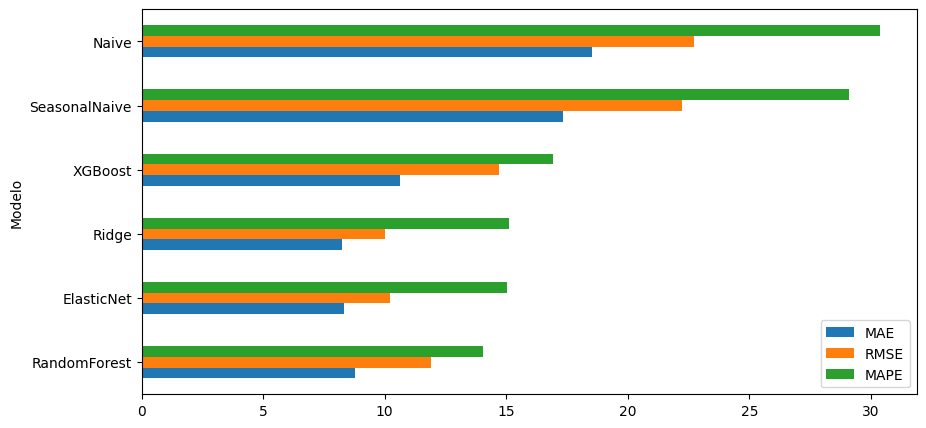

In [13]:
df_resultados.plot(kind='barh', figsize=(10,5))

## 7. GridSearch

Tres principales modelos

### 7.1 Random Forest

In [14]:
rf = RandomForestRegressor(random_state=42)

param_rf = {
    "n_estimators": [200, 400],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Mejores parámetros RF:")
print(grid_rf.best_params_)


Mejores parámetros RF:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


### 7.2 Ridge

In [15]:
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

param_ridge = {
    "model__alpha": np.logspace(-4, 4, 20)
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_ridge,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_ridge.fit(X, y)

print("Mejores parámetros Ridge:")
print(grid_ridge.best_params_)


Mejores parámetros Ridge:
{'model__alpha': np.float64(0.615848211066026)}


### 7.3 Elastic Net

In [16]:
pipe_en = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000))
])

param_en = {
    "model__alpha": np.logspace(-3, 1, 8),
    "model__l1_ratio": np.linspace(0.1, 0.9, 7)
}

grid_en = GridSearchCV(
    pipe_en,
    param_en,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_en.fit(X, y)

print("Mejores parámetros ElasticNet:")
print(grid_en.best_params_)

Mejores parámetros ElasticNet:
{'model__alpha': np.float64(0.7196856730011514), 'model__l1_ratio': np.float64(0.9)}


In [17]:
best_rf = grid_rf.best_estimator_
best_ridge = grid_ridge.best_estimator_
best_en = grid_en.best_estimator_

In [18]:
# xgb = XGBRegressor(random_state=42, verbosity=0)

# param_xgb = {
#     "n_estimators": [200, 400],
#     "max_depth": [2, 3, 4],
#     "learning_rate": [0.01, 0.05],
#     "subsample": [0.7, 0.9],
#     "colsample_bytree": [0.7, 0.9]
# }

# grid_xgb = GridSearchCV(
#     xgb,
#     param_xgb,
#     cv=tscv,
#     scoring="neg_mean_absolute_error",
#     n_jobs=-1
# )

# grid_xgb.fit(X, y)

# print("Mejores parámetros XGB:")
# print(grid_xgb.best_params_)


## 8. Resultados
### 8.1 Evaluación final con desviación estándar

In [19]:
def evaluacion_final(tscv):
  resultados = []
  errores_modelos = {}

  for nombre, model in modelos.items():
      maes, rmses, mapes = [], [], []
      errores_totales = []

      for train_idx, test_idx in tscv.split(X):
          X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
          y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

          model.fit(X_train, y_train)
          y_pred = model.predict(X_test)

          maes.append(mean_absolute_error(y_test, y_pred))
          rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
          mapes.append(mape(y_test, y_pred))

          errores_totales.extend(y_test.values - y_pred)

      resultados.append({
          "Modelo": nombre,
          "MAE": np.mean(maes),
          "RMSE": np.mean(rmses),
          "MAPE": np.mean(mapes),
          "Std MAPE": np.std(mapes)
      })

      errores_modelos[nombre] = np.array(errores_totales)

  df_final = pd.DataFrame(resultados).set_index("Modelo")
  df_final = df_final.sort_values("MAPE")

  return df_final, errores_modelos

In [20]:
tscv = TimeSeriesSplit(n_splits=3, test_size=24)

modelos = {
    "RandomForest": best_rf,
    "Ridge": best_ridge,
    "ElasticNet": best_en
}

df_final, errores_modelos = evaluacion_final(tscv)

print(df_final)

                   MAE       RMSE       MAPE  Std MAPE
Modelo                                                
ElasticNet    6.596886   8.549200  12.797689  4.104305
Ridge         7.478263   9.172598  16.354556  4.307975
RandomForest  8.172047  10.457000  16.595728  5.807576


### 8.2 Análisis de robustez

In [21]:
tscv_robust = TimeSeriesSplit(n_splits=4, test_size=18)
df_final, errores_modelos = evaluacion_final(tscv_robust)
print(df_final)

                   MAE       RMSE       MAPE  Std MAPE
Modelo                                                
ElasticNet    7.224512   9.229669  13.819345  4.086205
RandomForest  8.515269  10.581865  17.551685  5.918651
Ridge         8.802748  10.768949  18.359920  6.667349


### 8.3 Diebold-Marino

In [22]:
def dm_test_manual(e1, e2, h=1, power=2):
    d = np.abs(e1)**power - np.abs(e2)**power
    mean_d = np.mean(d)
    n = len(d)

    var_d = np.var(d, ddof=1)
    DM_stat = mean_d / np.sqrt(var_d / n)

    p_value = 2 * t.sf(np.abs(DM_stat), df=n-1)

    return DM_stat, p_value


In [23]:
top2 = df_final.head(2).index.tolist()

e1 = errores_modelos[top2[0]]
e2 = errores_modelos[top2[1]]

dm_stat, p_val = dm_test_manual(e1, e2)

print(f"Comparación DM entre {top2[0]} y {top2[1]}")
print(f"Estadístico DM: {dm_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("La diferencia es estadísticamente significativa.")
else:
    print("No hay diferencia estadísticamente significativa.")


Comparación DM entre ElasticNet y RandomForest
Estadístico DM: -1.5906
p-value: 0.1162
No hay diferencia estadísticamente significativa.


Se realizó un análisis de sensibilidad modificando la configuración de validación temporal (5 particiones con ventanas de prueba de 18 meses). Los resultados muestran que el orden relativo de desempeño entre modelos se mantiene estable, con diferencias marginales entre ElasticNet y Ridge. Esto sugiere que la superioridad observada no es un artefacto del esquema de partición original, sino un resultado consistente.

## 9. Conclusiones

Aunque ElasticNet presenta el menor error promedio (MAPE = 12.80%), la prueba de Diebold–Mariano indica que no existe diferencia estadísticamente significativa respecto a Random Fores (p = 0.1162). Por lo tanto, ambos modelos muestran desempeño predictivo comparable.

### Cuál modelo elegir?
- ElasticNet: Es más simple, más interpretable, coeficientes analizables.
- Ridge (Potencia predictiva): Captra no linealidades, más flexible
- Rabdom Forest(Robustez): Más estable entre periodods

ElasticNet presenta el mejor desempeño promedio, sin diferencias estadísticamente significativas respecto a Ridge. Los resultados son robustos a cambios en la configuración de validación temporal.

#Conclusiones

El presente estudio tuvo como objetivo principal desarrollar un modelo con alta capacidad predictiva para estimar la fluctuación mensual del precio del aguacate en México durante el periodo 2015–2025.

Se evaluaron distintos enfoques multivariados de machine learning, incluyendo ElasticNet, Random Forest y Ridge, utilizando validación cruzada temporal y métricas fuera de muestra (MAE, RMSE, MAPE y desviación estándar del MAPE).

Dados los resultados y la flexibilidad del modelo ElasticNet determinamos como el mejor modelo predictivo superando los demás modelos evaluados.